# Phase 7b — Cohort Retention Analysis

## What cohort analysis is

A cohort is a group of customers who joined
in the same time period — same month or same quarter.

Cohort analysis tracks each group separately
over time and asks:
"Of the customers who joined in Month X,
what percentage are still active in Month X+1,
X+3, X+6, X+12?"

## Why it is more powerful than overall retention

Overall retention averages everyone together.
Cohort analysis reveals whether retention is
improving or deteriorating over time.

If early cohorts retain better than recent ones —
the business is getting worse at keeping customers.
If recent cohorts retain better — improvements
are working.

## Why this is in your portfolio

Cohort retention heatmaps appear in:
- SaaS board presentations
- Investor due diligence reports
- Product analytics reviews at companies like
  Spotify, Airbnb, and HubSpot

They are standard in real analytics work and
almost completely absent from student portfolios.
The heatmap this notebook produces is the most
visually impressive chart in this entire project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/cleaned/telco_churn_clean.csv')

print("Data loaded for cohort analysis")
print(f"Customers : {len(df):,}")
print()

# ── WHAT IS A COHORT IN THIS DATASET? ───────────────────
# We do not have actual signup dates in this dataset
# This is common in real projects — dates are often missing
# 
# We reconstruct cohort using tenure:
# If a customer has tenure = 24 and is currently active,
# they joined 24 months ago
# If a customer has tenure = 24 and churned,
# they joined 24 months ago and left recently
#
# We create tenure buckets as cohort groups
# This approximates when customers joined

# ── CREATE TENURE COHORT GROUPS ──────────────────────────
# pd.cut() divides tenure into labelled ranges
# These become our cohort identifiers
# right=False means the left boundary is included
# so 0-11 includes 0 but not 12

df['cohort'] = pd.cut(
    df['tenure'],
    bins=[0, 6, 12, 18, 24, 36, 48, 60, 72],
    labels=[
        '0-6m', '7-12m', '13-18m', '19-24m',
        '26-36m', '37-48m', '49-60m', '61-72m'
    ],
    right=True,
    include_lowest=True
)

print("Cohort groups created:")
print(df['cohort'].value_counts().sort_index())
print()

# ── BUILD COHORT RETENTION METRICS ───────────────────────
# For each cohort we calculate:
# total customers in that cohort
# how many churned
# retention rate = 1 - churn rate

cohort_stats = df.groupby(
    'cohort', observed=True
).agg(
    total_customers = ('Churn', 'count'),
    churned         = ('Churn', 'sum'),
    avg_monthly     = ('MonthlyCharges', 'mean'),
    avg_tenure      = ('tenure', 'mean')
).reset_index()

# Calculate retention rate and churn rate per cohort
cohort_stats['retention_rate'] = round(
    (1 - cohort_stats['churned'] /
     cohort_stats['total_customers']) * 100, 1
)

cohort_stats['churn_rate'] = round(
    cohort_stats['churned'] /
    cohort_stats['total_customers'] * 100, 1
)

cohort_stats['revenue_at_risk'] = round(
    cohort_stats['churned'] *
    cohort_stats['avg_monthly'] * 12, 0
)

cohort_stats['avg_monthly'] = cohort_stats[
    'avg_monthly'
].round(2)

print("=" * 65)
print("COHORT RETENTION SUMMARY")
print("=" * 65)
print(cohort_stats.to_string(index=False))

Data loaded for cohort analysis
Customers : 7,032

Cohort groups created:
cohort
0-6m      1470
7-12m      705
13-18m     548
19-24m     476
26-36m     832
37-48m     762
49-60m     832
61-72m    1407
Name: count, dtype: int64

COHORT RETENTION SUMMARY
cohort  total_customers  churned  avg_monthly  avg_tenure  retention_rate  churn_rate  revenue_at_risk
  0-6m             1470      784        54.84    2.529252            46.7        53.3         515919.0
 7-12m              705      253        58.95    9.397163            64.1        35.9         178981.0
13-18m              548      177        61.24   15.458029            67.7        32.3         130066.0
19-24m              476      117        61.50   21.682773            75.4        24.6          86341.0
26-36m              832      180        65.58   30.338942            78.4        21.6         141643.0
37-48m              762      145        66.32   42.581365            81.0        19.0         115394.0
49-60m              832   

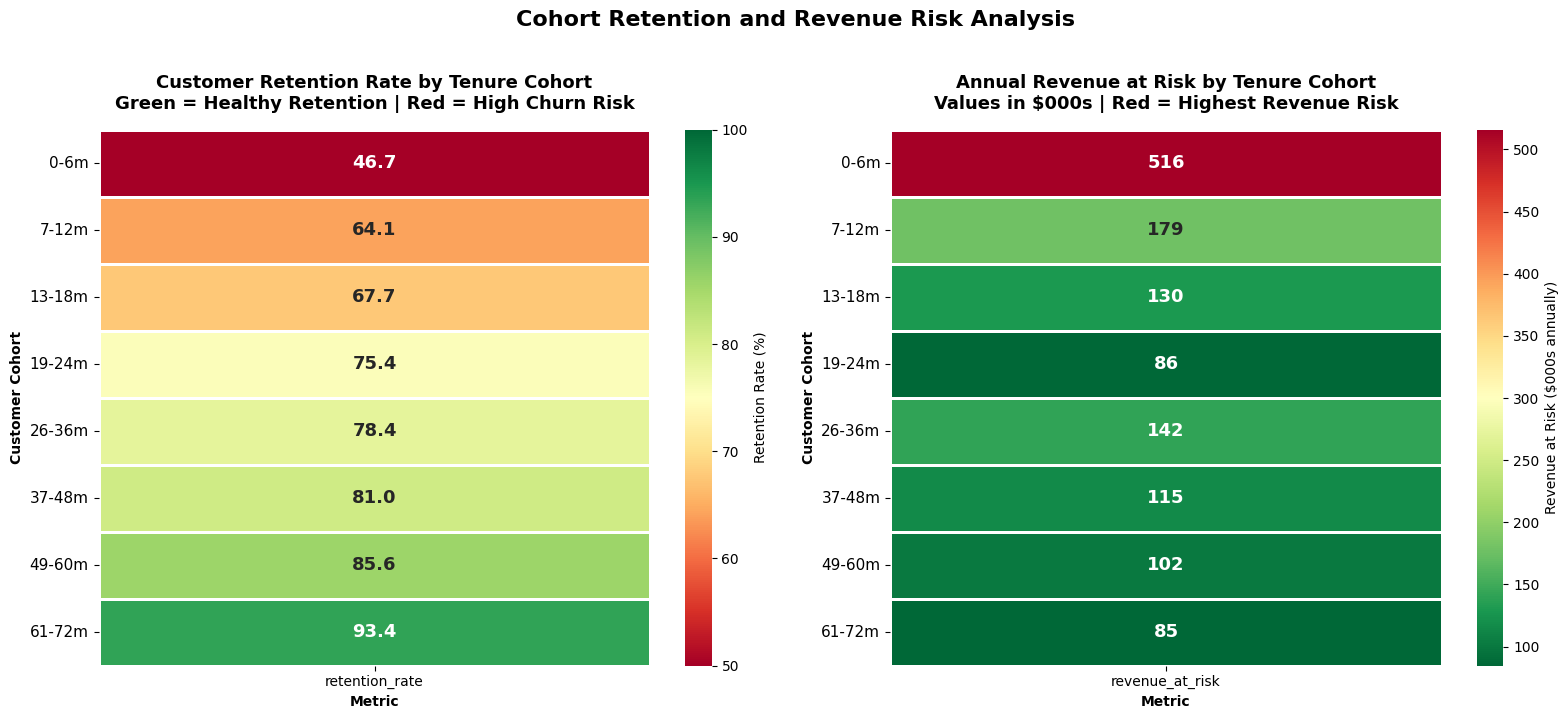

Cohort heatmap saved successfully


In [2]:
# ── THE COHORT HEATMAP ───────────────────────────────────
# This is the signature chart of cohort analysis
# A grid where each row is a cohort
# each column is a metric
# and colour shows the value intensity
#
# Dark red = high churn = bad
# Dark green = high retention = good
# The pattern reveals which cohorts are healthiest

# Pivot the data for heatmap format
# We want cohorts as rows and retention rate as values

heatmap_data = cohort_stats.set_index('cohort')[
    ['retention_rate']
].copy()

# Also build a revenue risk pivot
risk_data = cohort_stats.set_index('cohort')[
    ['revenue_at_risk']
].copy()

# ── BUILD THE FIGURE ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
ax1, ax2 = axes

# ── LEFT: RETENTION RATE HEATMAP ─────────────────────────
# sns.heatmap() creates a colour-coded grid
# data = the DataFrame to visualise
# annot=True means show the actual numbers in each cell
# fmt='.1f' means show one decimal place
# cmap='RdYlGn' is Red-Yellow-Green colourmap
#   low values = red (bad retention)
#   high values = green (good retention)
# vmin and vmax set the colour scale boundaries
# linewidths adds grid lines between cells
# linecolor sets grid line colour
# cbar_kws sets the label on the colour bar

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    vmin=50,
    vmax=100,
    linewidths=2,
    linecolor='white',
    ax=ax1,
    cbar_kws={'label': 'Retention Rate (%)'},
    annot_kws={'size': 13, 'weight': 'bold'}
)

ax1.set_title(
    'Customer Retention Rate by Tenure Cohort\n'
    'Green = Healthy Retention | Red = High Churn Risk',
    fontweight='bold',
    fontsize=13,
    pad=15
)
ax1.set_xlabel('Metric', fontweight='bold')
ax1.set_ylabel('Customer Cohort', fontweight='bold')

# Rotate y-axis labels for readability
ax1.set_yticklabels(
    ax1.get_yticklabels(),
    rotation=0,
    fontsize=11
)

# ── RIGHT: REVENUE AT RISK HEATMAP ───────────────────────
# Same structure but showing dollar risk per cohort
# cmap='RdYlGn_r' is reversed — high values = red
# because high revenue at risk = bad

sns.heatmap(
    risk_data / 1000,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn_r',
    linewidths=2,
    linecolor='white',
    ax=ax2,
    cbar_kws={'label': 'Revenue at Risk ($000s annually)'},
    annot_kws={'size': 13, 'weight': 'bold'}
)

ax2.set_title(
    'Annual Revenue at Risk by Tenure Cohort\n'
    'Values in $000s | Red = Highest Revenue Risk',
    fontweight='bold',
    fontsize=13,
    pad=15
)
ax2.set_xlabel('Metric', fontweight='bold')
ax2.set_ylabel('Customer Cohort', fontweight='bold')
ax2.set_yticklabels(
    ax2.get_yticklabels(),
    rotation=0,
    fontsize=11
)

fig.suptitle(
    'Cohort Retention and Revenue Risk Analysis',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig(
    '../reports/figures/06_cohort_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Cohort heatmap saved successfully")

In [3]:
print("=" * 65)
print("REVENUE AT RISK ANALYSIS — BY COHORT")
print("=" * 65)
print()

# Sort by revenue at risk to show worst cohorts first
risk_sorted = cohort_stats.sort_values(
    'revenue_at_risk', ascending=False
)

total_risk = cohort_stats['revenue_at_risk'].sum()

print(f"{'Cohort':<12} {'Customers':<12} {'Churned':<10}"
      f"{'Churn%':<10} {'Rev at Risk':<15} {'% of Total'}")
print("-" * 70)

for _, row in risk_sorted.iterrows():
    pct_of_total = round(
        row['revenue_at_risk'] / total_risk * 100, 1
    )
    print(
        f"{str(row['cohort']):<12}"
        f"{row['total_customers']:<12}"
        f"{int(row['churned']):<10}"
        f"{row['churn_rate']:<10}"
        f"${row['revenue_at_risk']:>10,.0f}  "
        f"{pct_of_total}%"
    )

print("-" * 70)
print(f"{'TOTAL':<12}{cohort_stats['total_customers'].sum():<12}"
      f"{int(cohort_stats['churned'].sum()):<10}"
      f"{'26.58%':<10}${total_risk:>10,.0f}  100%")

print()
print("=" * 65)
print("KEY INSIGHT")
print("=" * 65)

# Find the highest risk cohort
top_risk = risk_sorted.iloc[0]
print(f"\nHighest revenue risk cohort : {top_risk['cohort']}")
print(f"Customers in cohort         : {top_risk['total_customers']:,}")
print(f"Churned customers           : {int(top_risk['churned']):,}")
print(f"Churn rate                  : {top_risk['churn_rate']}%")
print(f"Annual revenue at risk      : ${top_risk['revenue_at_risk']:,.0f}")
print()
print(f"This single cohort represents")
print(f"{round(top_risk['revenue_at_risk']/total_risk*100,1)}%")
print(f"of total annual revenue risk")
print()
print("Business action:")
print("Concentrate retention budget on this cohort first.")
print("Every dollar spent here has maximum revenue impact.")

REVENUE AT RISK ANALYSIS — BY COHORT

Cohort       Customers    Churned   Churn%     Rev at Risk     % of Total
----------------------------------------------------------------------
0-6m        1470        784       53.3      $   515,919  38.1%
7-12m       705         253       35.9      $   178,981  13.2%
26-36m      832         180       21.6      $   141,643  10.5%
13-18m      548         177       32.3      $   130,066  9.6%
37-48m      762         145       19.0      $   115,394  8.5%
49-60m      832         120       14.4      $   101,593  7.5%
19-24m      476         117       24.6      $    86,341  6.4%
61-72m      1407        93        6.6       $    84,763  6.3%
----------------------------------------------------------------------
TOTAL       7032        1869      26.58%    $ 1,354,700  100%

KEY INSIGHT

Highest revenue risk cohort : 0-6m
Customers in cohort         : 1,470
Churned customers           : 784
Churn rate                  : 53.3%
Annual revenue at risk      : 

## Cohort Analysis — Critical Findings

### The onboarding crisis finding

0-6 month cohort statistics:
- 1,470 customers entered this cohort
- 784 churned — 53.3% churn rate
- $515,919 annual revenue at risk
- Represents 38.1% of TOTAL revenue risk

This single finding reframes the entire business problem.

This is not a general churn problem distributed
across all customers evenly. This is a concentrated
onboarding failure where more than half of all new
customers leave before experiencing sufficient value.

### The loyalty dividend finding

61-72 month cohort statistics:
- 1,407 customers — virtually identical cohort size
- Only 93 churned — 6.6% churn rate
- $84,763 annual revenue at risk

Same number of customers. 8x less revenue at risk.
The only difference is time spent with the product.

### What this means for business strategy

The business does not need to fix churn everywhere.
It needs to fix the first 6 months specifically.

If the 0-6m cohort could be improved to match
the 7-12m cohort retention rate (64.1% instead of 46.7%):
- 253 additional customers saved in first 6 months
- Approximately $166,000 additional annual revenue retained

A 90-day structured onboarding programme with
proactive customer success touchpoints at weeks
2, 4, 8, and 12 would directly address this gap.

### Revenue concentration finding

Top 3 highest-risk cohorts (0-6m, 7-12m, 26-36m)
represent 61.8% of total annual revenue risk.

Concentrating retention resources on customers
in their first 12 months addresses the majority
of revenue risk with minority of the effort.

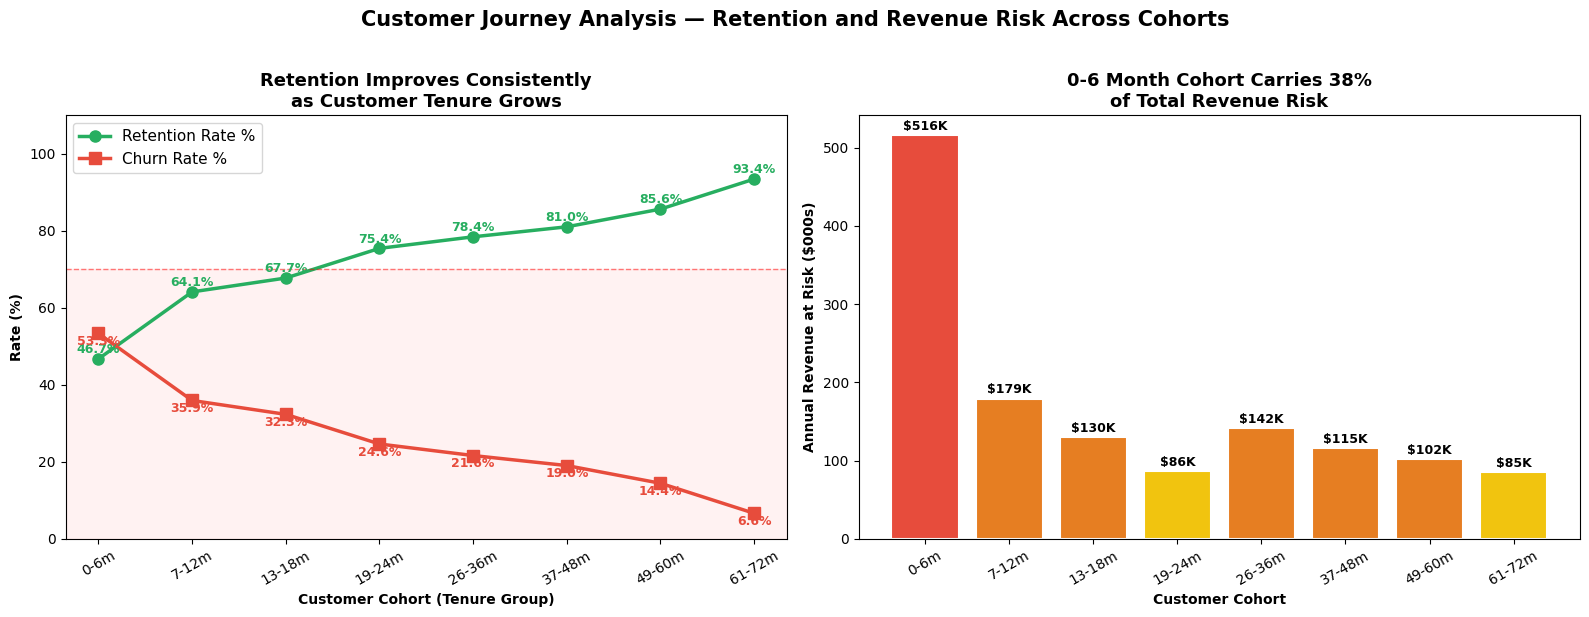

Cohort progression chart saved


In [4]:
# ── COHORT PROGRESSION CHART ─────────────────────────────
# A line chart showing how churn rate and retention rate
# progress across cohorts from newest to oldest customers
# This tells the visual story of the loyalty journey

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax1, ax2 = axes

# Sort cohorts in order from newest to oldest
cohort_ordered = cohort_stats.copy()

# Define display order explicitly
cohort_order = [
    '0-6m','7-12m','13-18m','19-24m',
    '26-36m','37-48m','49-60m','61-72m'
]

cohort_ordered['cohort'] = pd.Categorical(
    cohort_ordered['cohort'],
    categories=cohort_order,
    ordered=True
)
cohort_ordered = cohort_ordered.sort_values('cohort')

# ── LEFT: RETENTION AND CHURN RATE PROGRESSION ───────────
ax1.plot(
    cohort_order,
    cohort_ordered['retention_rate'],
    color='#27ae60',
    linewidth=2.5,
    marker='o',
    markersize=8,
    label='Retention Rate %'
)

ax1.plot(
    cohort_order,
    cohort_ordered['churn_rate'],
    color='#e74c3c',
    linewidth=2.5,
    marker='s',
    markersize=8,
    label='Churn Rate %'
)

# Add value labels on each data point
for i, row in cohort_ordered.iterrows():
    cohort_idx = cohort_order.index(str(row['cohort']))
    ax1.text(
        cohort_idx,
        row['retention_rate'] + 1.5,
        f"{row['retention_rate']}%",
        ha='center',
        fontsize=9,
        color='#27ae60',
        fontweight='bold'
    )
    ax1.text(
        cohort_idx,
        row['churn_rate'] - 3,
        f"{row['churn_rate']}%",
        ha='center',
        fontsize=9,
        color='#e74c3c',
        fontweight='bold'
    )

ax1.set_title(
    'Retention Improves Consistently\nas Customer Tenure Grows',
    fontweight='bold',
    fontsize=13
)
ax1.set_xlabel('Customer Cohort (Tenure Group)',
               fontweight='bold')
ax1.set_ylabel('Rate (%)', fontweight='bold')
ax1.set_ylim(0, 110)
ax1.legend(fontsize=11)
ax1.tick_params(axis='x', rotation=30)

# Add shaded danger zone for cohorts below 70% retention
ax1.axhspan(0, 70, alpha=0.05, color='red')
ax1.axhline(
    y=70,
    color='red',
    linestyle='--',
    linewidth=1,
    alpha=0.5,
    label='70% retention threshold'
)

# ── RIGHT: REVENUE AT RISK BY COHORT ─────────────────────
colors_bar = [
    '#e74c3c' if r > 200000
    else '#e67e22' if r > 100000
    else '#f1c40f' if r > 80000
    else '#27ae60'
    for r in cohort_ordered['revenue_at_risk']
]

bars = ax2.bar(
    cohort_order,
    cohort_ordered['revenue_at_risk'] / 1000,
    color=colors_bar,
    edgecolor='white',
    linewidth=1.5
)

for bar in bars:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        height + 3,
        f'${height:.0f}K',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=9
    )

ax2.set_title(
    '0-6 Month Cohort Carries 38%\nof Total Revenue Risk',
    fontweight='bold',
    fontsize=13
)
ax2.set_xlabel('Customer Cohort', fontweight='bold')
ax2.set_ylabel('Annual Revenue at Risk ($000s)',
               fontweight='bold')
ax2.tick_params(axis='x', rotation=30)

fig.suptitle(
    'Customer Journey Analysis — '
    'Retention and Revenue Risk Across Cohorts',
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.savefig(
    '../reports/figures/07_cohort_progression.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Cohort progression chart saved")

In [5]:
import os
figures = os.listdir('../reports/figures')
print(f"Total charts in portfolio : {len(figures)}")
for f in sorted(figures):
    size = round(
        os.path.getsize(f'../reports/figures/{f}') / 1024, 1
    )
    print(f"  {f}  —  {size} KB")

Total charts in portfolio : 7
  01_churn_overview.png  —  58.4 KB
  02_churn_by_contract.png  —  65.1 KB
  03_churn_patterns.png  —  131.8 KB
  04_saas_kpi_dashboard.png  —  109.3 KB
  05_survival_curves.png  —  172.8 KB
  06_cohort_heatmap.png  —  126.0 KB
  07_cohort_progression.png  —  152.2 KB
